#1 Import functions 

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import numpy as np
from PIL import Image
import requests
import matplotlib.pyplot as plt
import chromadb

#2 Create helper function for image display later 

In [ ]:
def show_images(image_urls, titles):
    # Adjust subplot size to accommodate 6 images (query + 5 results)
    fig, axes = plt.subplots(1, len(image_urls), figsize=(25, 6))
    if len(image_urls) == 1:
        axes = [axes]

    for ax, url, title in zip(axes, image_urls, titles):
        try:
            # Check if the url is a local file path using os.path.exists
            if os.path.exists(url):
                image = Image.open(url)
            # If not, it's a URL to be downloaded
            else:
                image = Image.open(requests.get(url, stream=True).raw)
            ax.imshow(image)
            ax.set_title(title, fontsize=10, pad=10)
            ax.axis('off')
        except Exception as e:
            print(f"Could not display image at {url}: {e}")

    plt.tight_layout()
    plt.show()

#3 Import the pre-trained CLIP model using SentenceTransformer

In [21]:
model = SentenceTransformer('clip-ViT-B-32')

#4 Establish connection to ChromaDB

In [23]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get the API key and other details from environment variables
api_key = os.getenv("CHROMA_API_KEY")
tenant_id = os.getenv("CHROMA_TENANT")
database_name = os.getenv("CHROMA_DATABASE")

# Check if the variables were loaded correctly
if not api_key:
    print("Error: API key not found. Make sure it's in your .env file.")
else:
    # Use the variables to create the client
    client = chromadb.CloudClient(
        api_key=api_key,
        tenant=tenant_id,
        database=database_name
    )
    print("ChromaDB client initialized successfully!")

ChromaDB client initialized successfully!


#5 Load the df

In [ ]:
# Load our selected dataset --> change to big one if needed

def load_local_data():
    """Load the dataframe CSV file in the 'sample1000BALANCED' directory."""
    # Use the new relative path to the CSV file
    df = pd.read_csv("sample1000BALANCED/data_sampling1000_topstyles10.csv")
    return df

# Replace the previous line with the new function call
df = load_local_data()

# Get or create a collection. This is where your embeddings will live.
# The name "wikiart_embeddings" is an arbitrary name you choose.
collection = client.get_or_create_collection(name="wikiart_1000images")

#6 Define an uploader for .jpg, .jpeg. and .png images 

In [ ]:
uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False  # Set to False to only allow one file at a time
)

display(uploader)

#7 Use most similar images, compare to df, and show results 

——————————————————————————————————————————————————
Querying with local image: Paul_Cézanne_-_The_Basket_of_Apples_-_1926.252_-_Art_Institute_of_Chicago.jpg



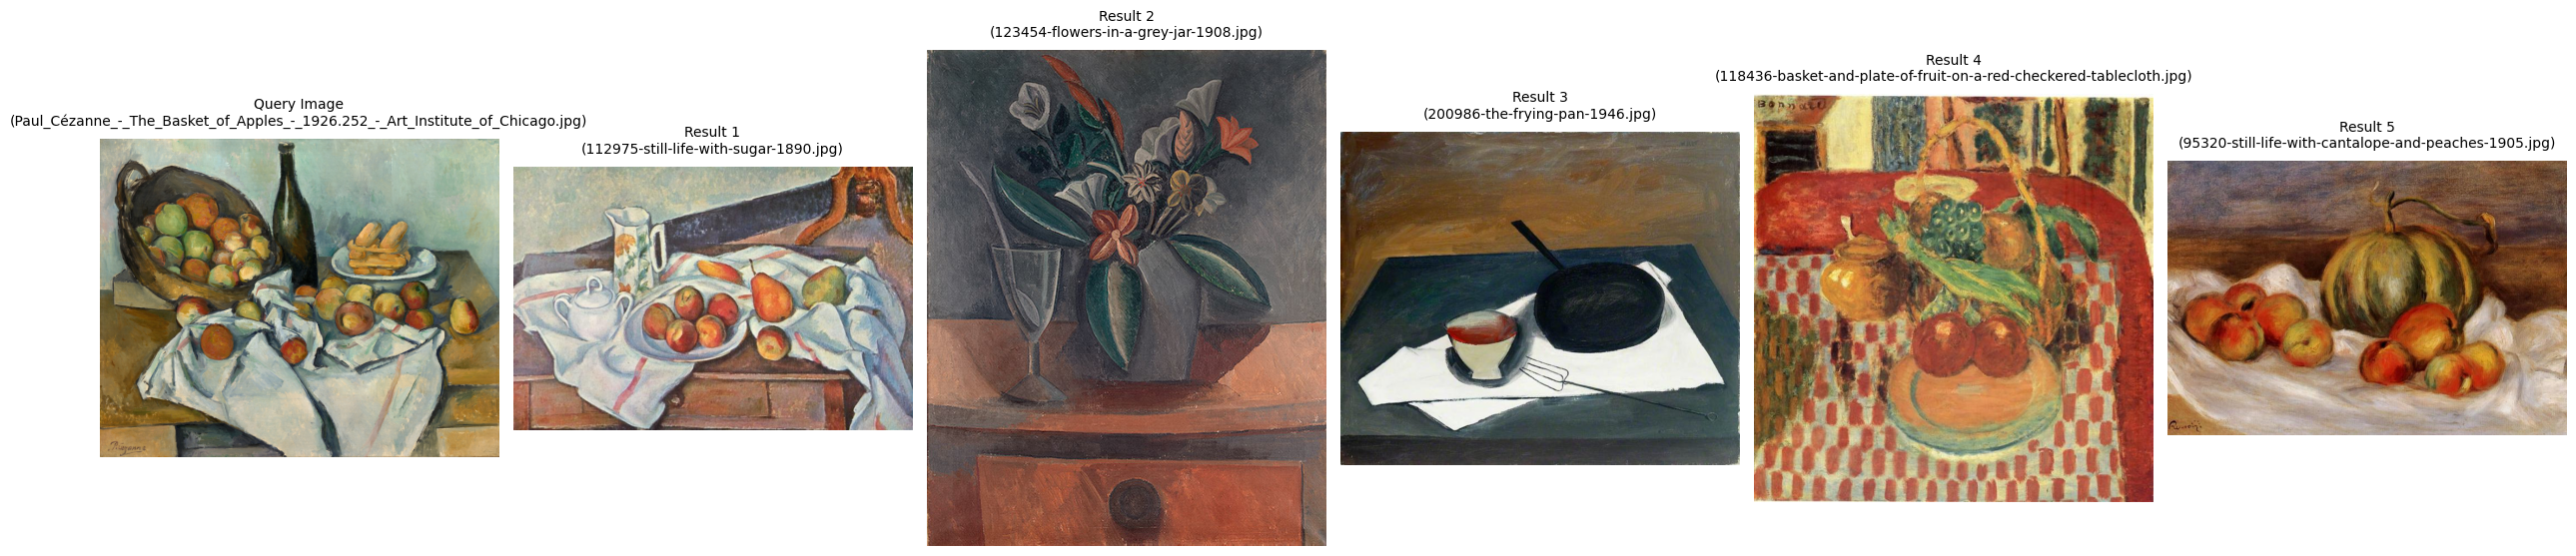

——————————————————————————————————————————————————
Querying with local image: Piet_Mondriaan,_1942_-_New_York_City_I.jpg



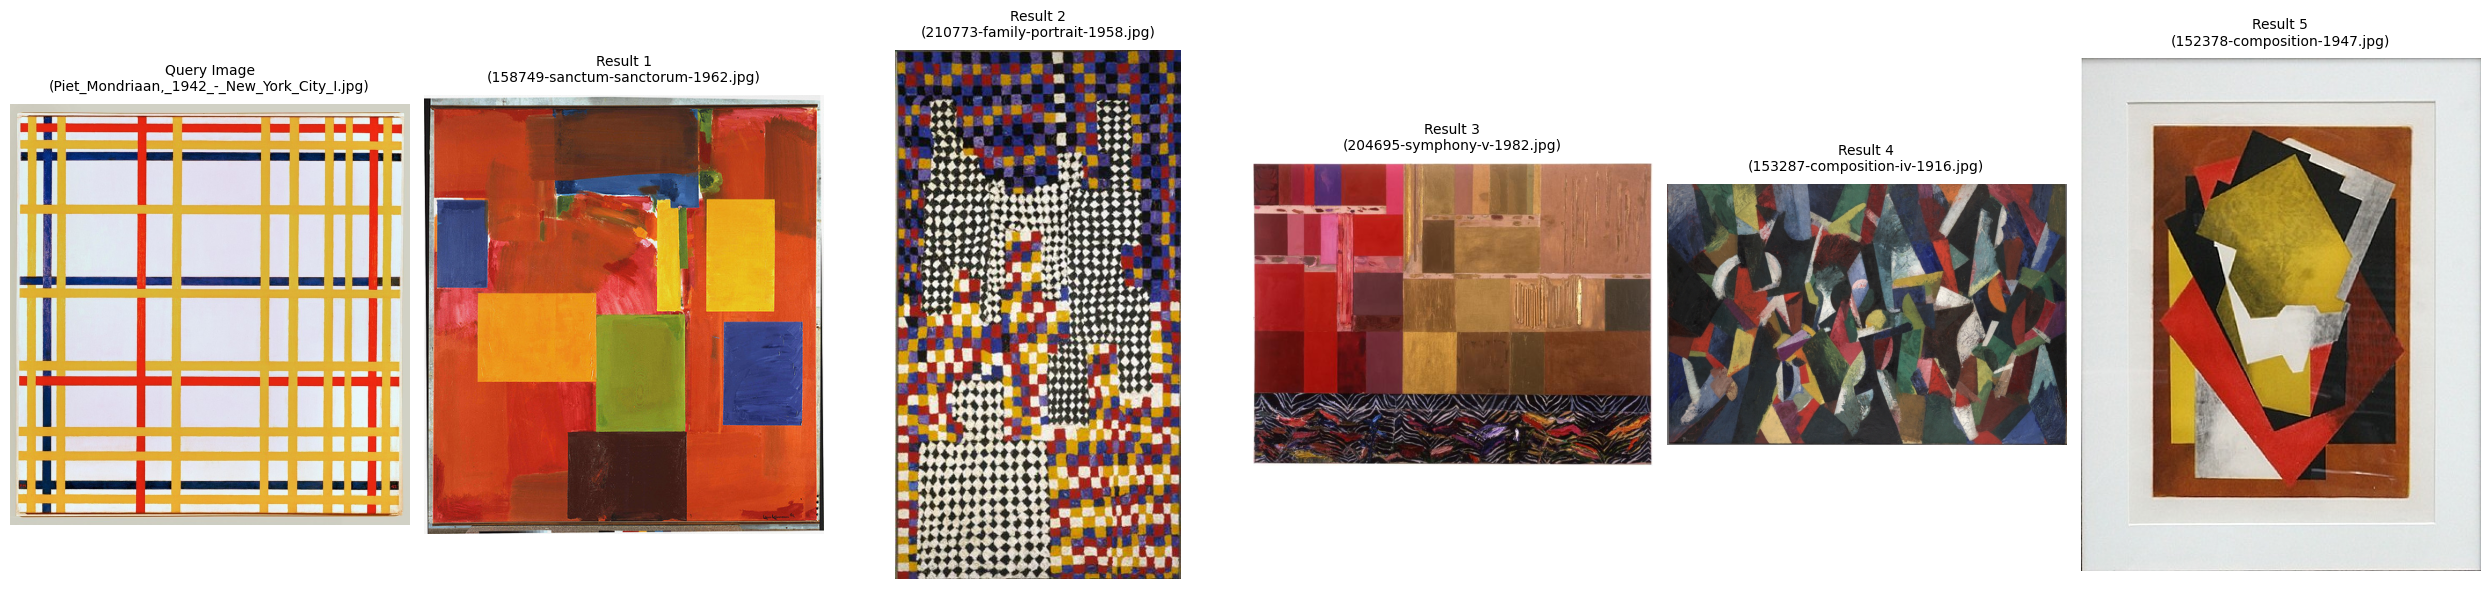

——————————————————————————————————————————————————
Querying with local image: Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg



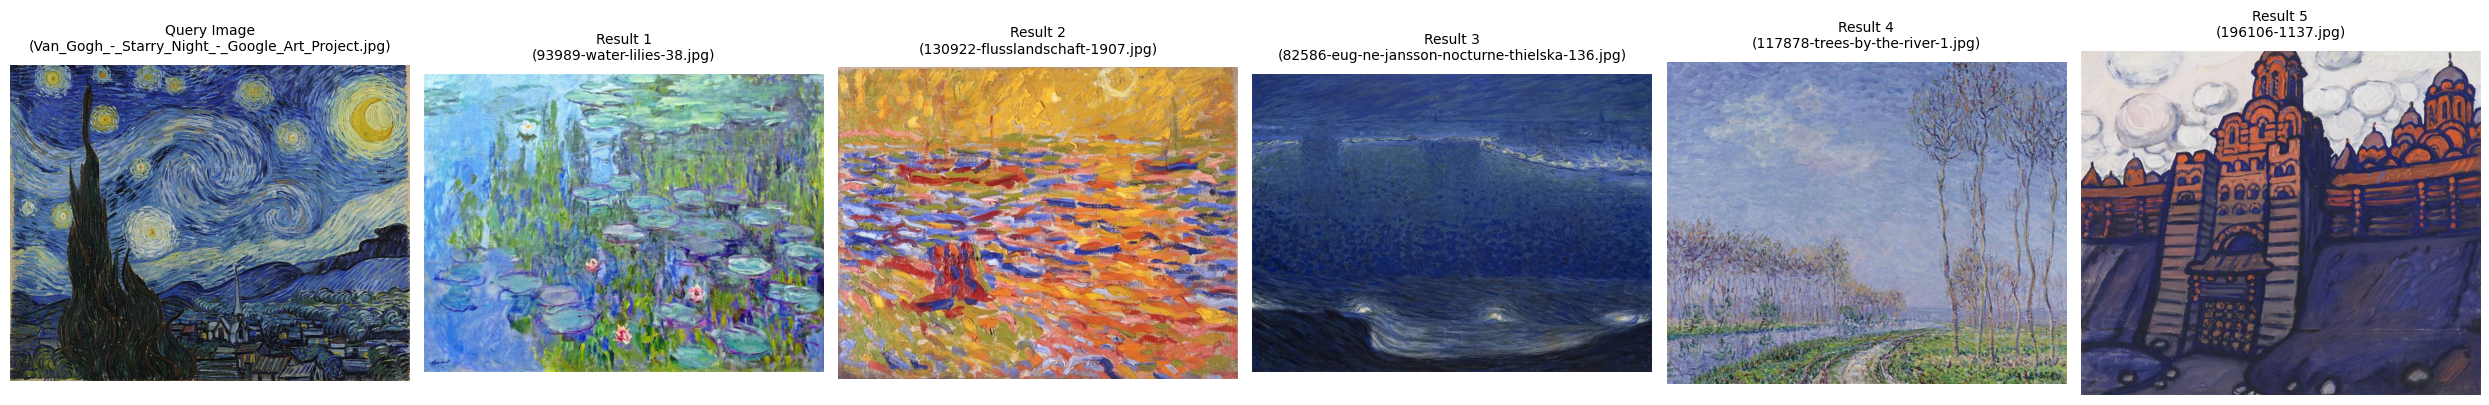

——————————————————————————————————————————————————
Querying with local image: Two_Young_Girls_at_the_Piano_MET_rl1975.1.201.R.jpg



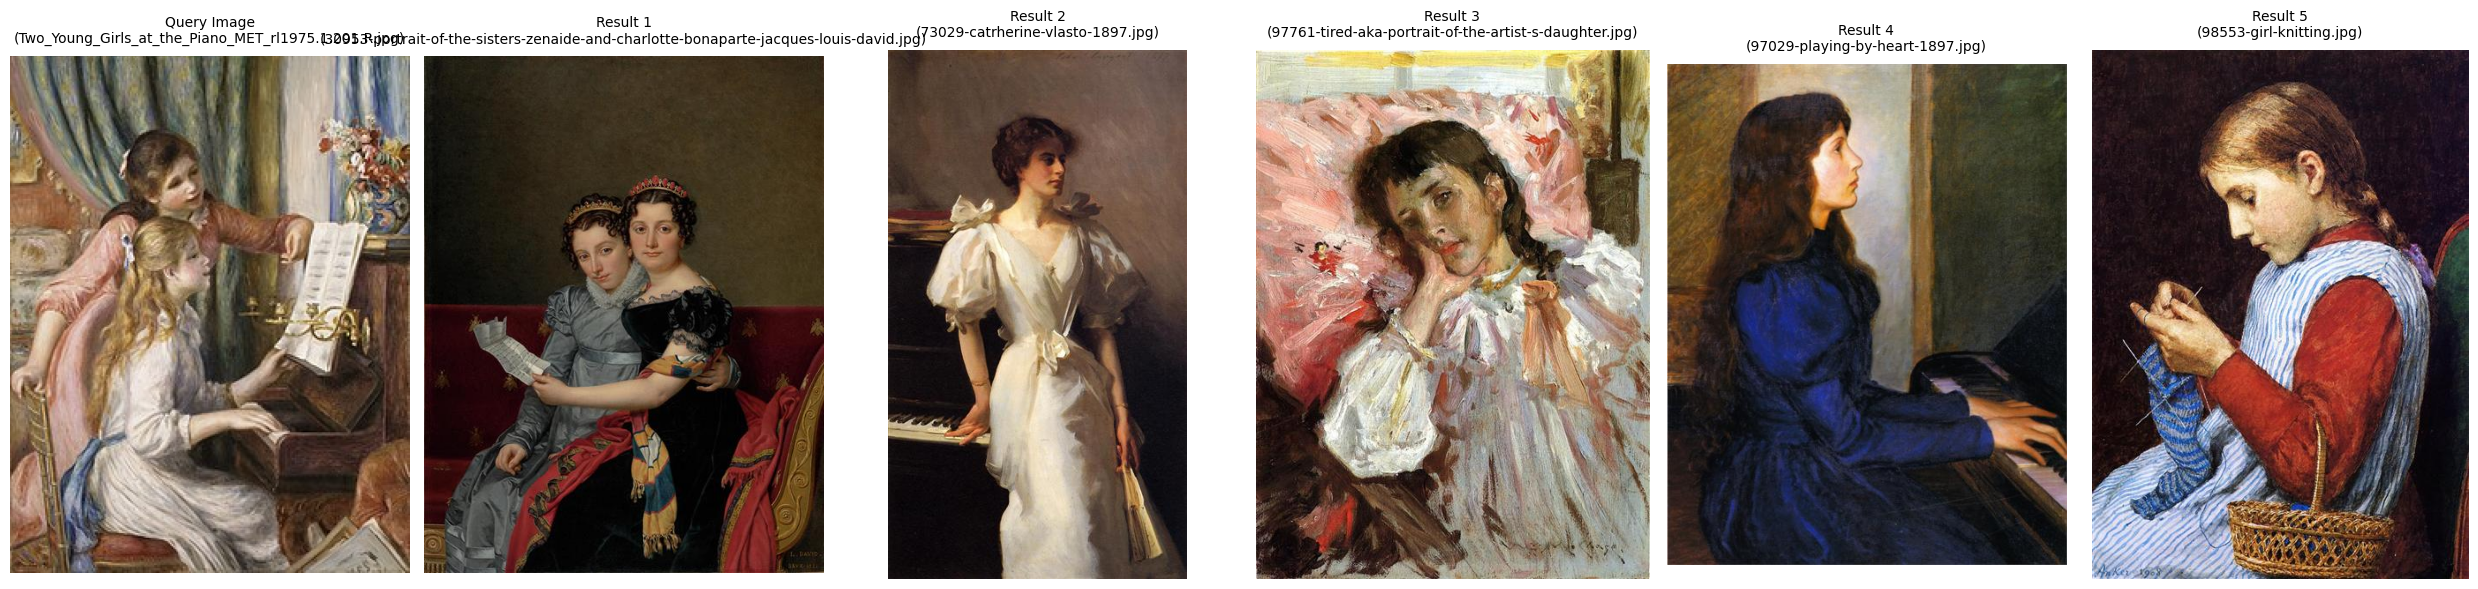

In [ ]:
# Define the local query images by creating a list of paths to your four locally downloaded images.
local_query_images = [
    "raw_data/Images to try/Paul_Cézanne_-_The_Basket_of_Apples_-_1926.252_-_Art_Institute_of_Chicago.jpg",
    "raw_data/Images to try/Piet_Mondriaan,_1942_-_New_York_City_I.jpg",
    "raw_data/Images to try/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg",
    "raw_data/Images to try/Two_Young_Girls_at_the_Piano_MET_rl1975.1.201.R.jpg"
]

# Iterate through each query image
for query_image_path in local_query_images:
    try:
        # Load the image from the local file path
        query_image = Image.open(query_image_path)

        # Use the CLIP model to encode the image
        query_embedding = model.encode(query_image).tolist()

        # Use ChromaDB to find the most similar images and get top 5 results
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=5, # Since the query image is not in the database, we ask for exactly 5.
        )

        # Print the results for the current query image
        print("—" * 50)
        print(f"Querying with local image: {os.path.basename(query_image_path)}\n")

        # Get the URLs and file names for the top 5 results from the ChromaDB results
        result_urls = [metadata['url'] for metadata in results['metadatas'][0]]
        result_file_names = [metadata['file_name'] for metadata in results['metadatas'][0]]

        # Prepare titles for visualization, including the file names
        result_titles = [f"Result {i+1}\n({name})" for i, name in enumerate(result_file_names)]

        # Add the query image and its title to the beginning of the lists
        all_urls = [query_image_path] + result_urls
        all_titles = [f"Query Image\n({os.path.basename(query_image_path)})"] + result_titles

        # Visualize the images!
        show_images(all_urls, all_titles)

    except Exception as e:
        print(f"Error processing image {query_image_path}: {e}")